In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
mouse = 28
day = 25

# good examples include 
#mice = [25, 25, 26, 27, 29, 28]
#days = [25, 24, 18, 26, 23, 25]

28 25
there are 104 non_grid and non_spatial_cells
there are 24 grid_cells
there are 100 non grid spatial cells
there are 4 non spatial cells
there are 7 speed cells
there are 135 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 3 modules with HDBSCAN for mouse 28 day 25
for each module , the number of points is: [ 2  4 18]


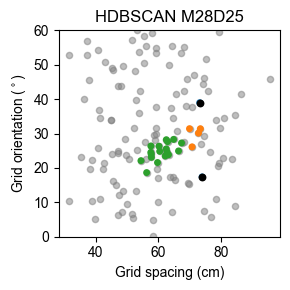

for module 0, there are 4 cells with average spacing 71.75766065742434
for module 1, there are 18 cells with average spacing 60.94923689327594
module 1 contains cells from ['ENTm3' 'ENTm5']
module 0 contains cells from ['ENTm3' 'ENTm5']


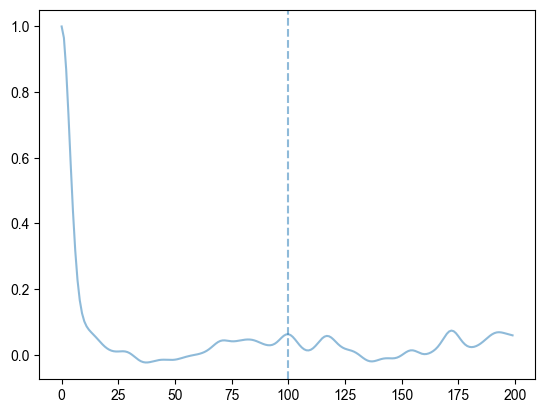

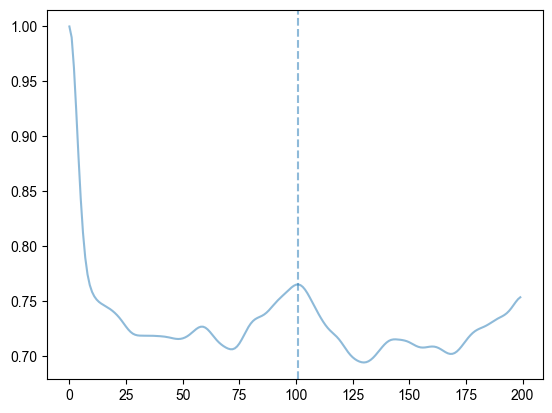

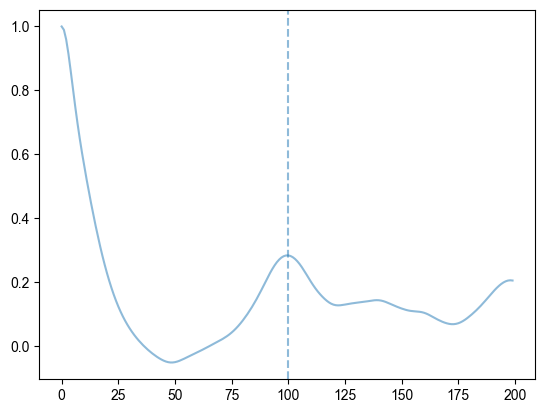

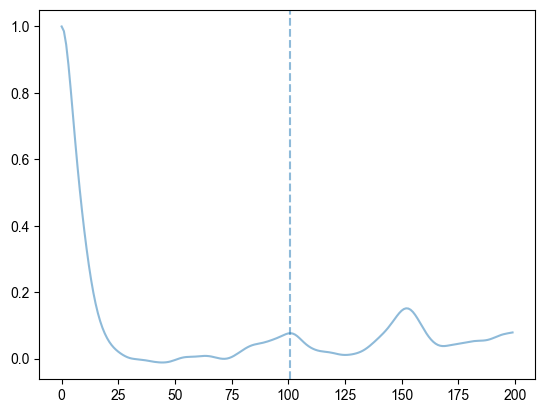

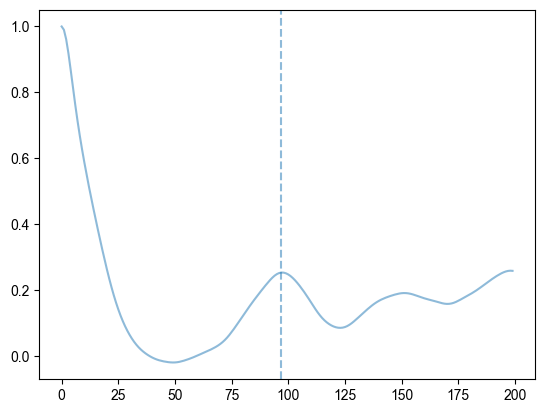

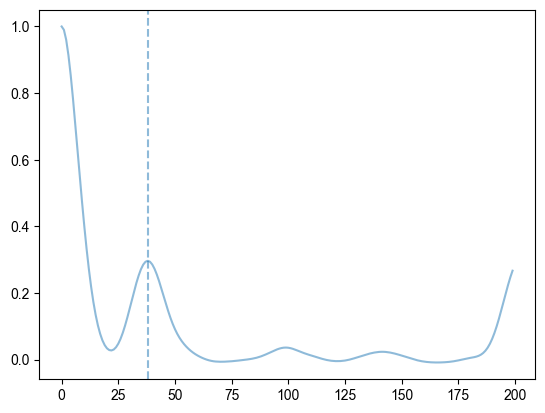

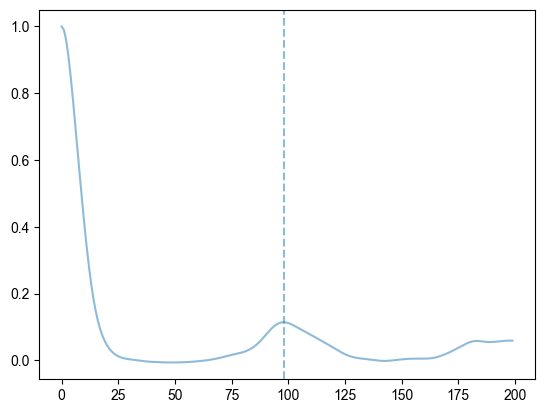

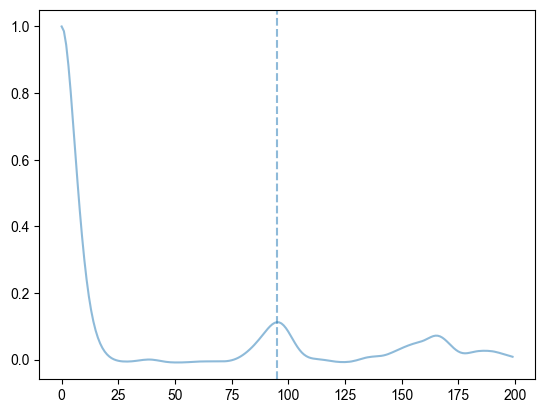

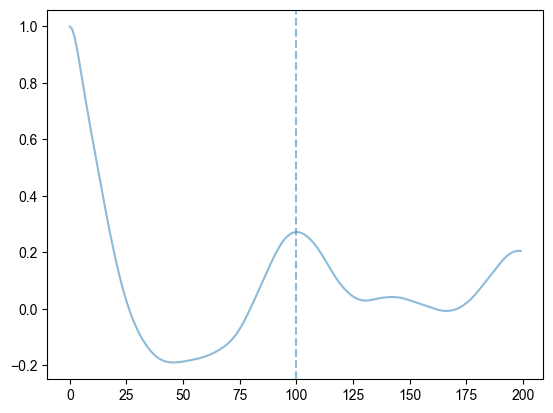

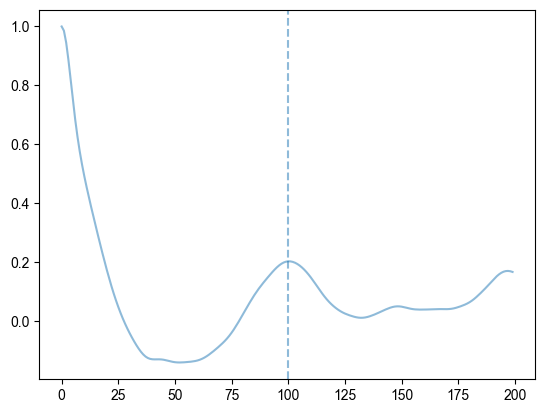

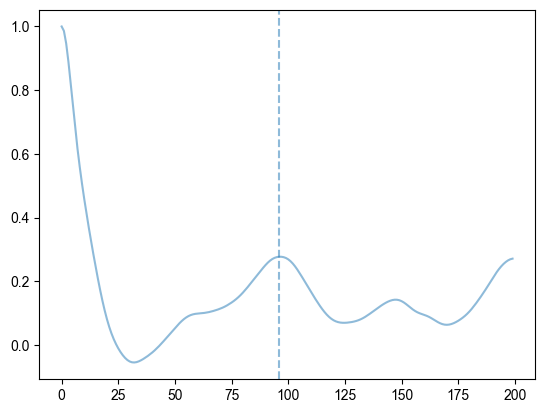

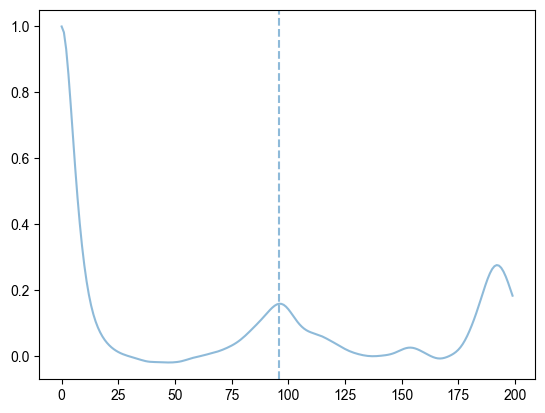

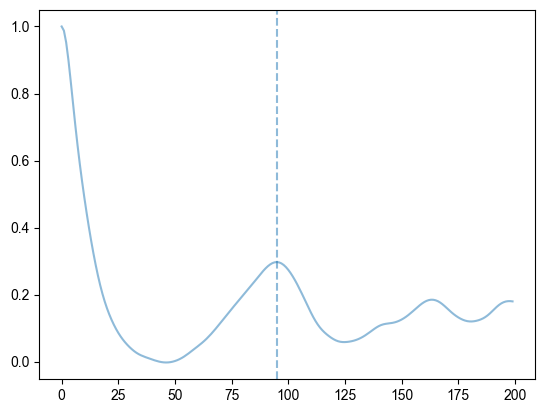

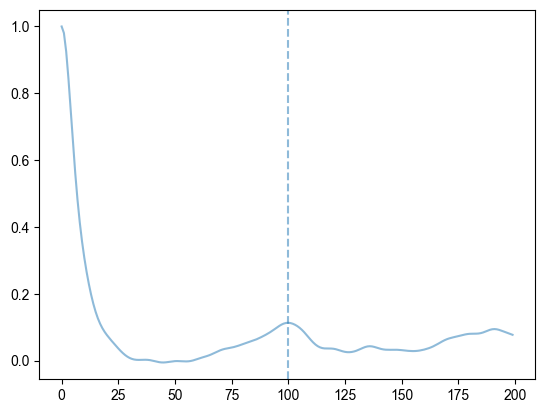

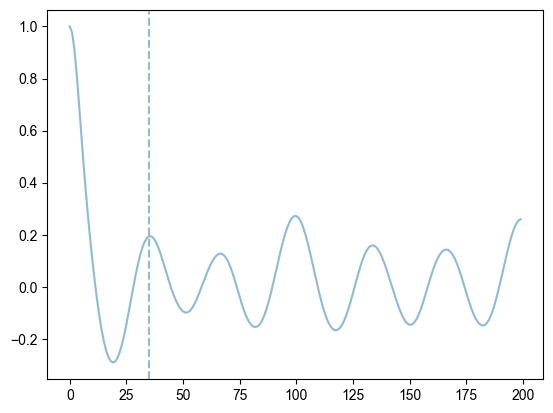

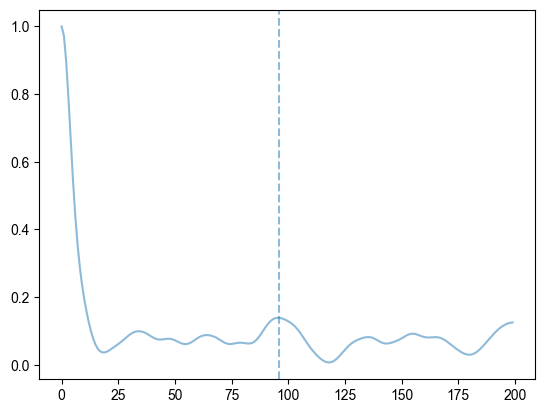

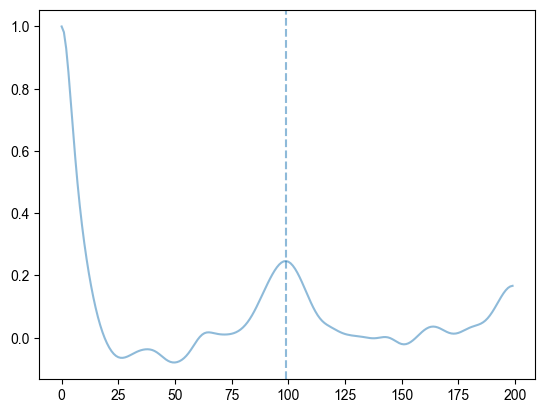

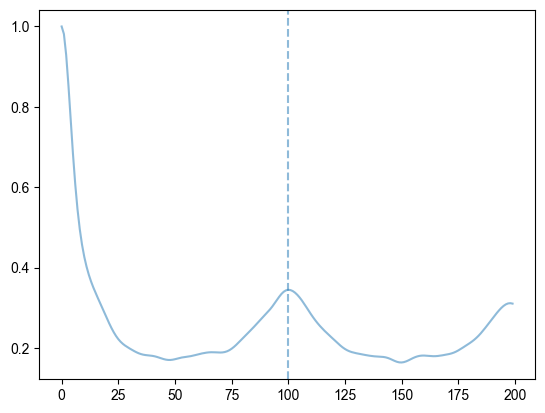

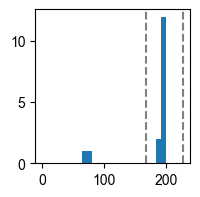

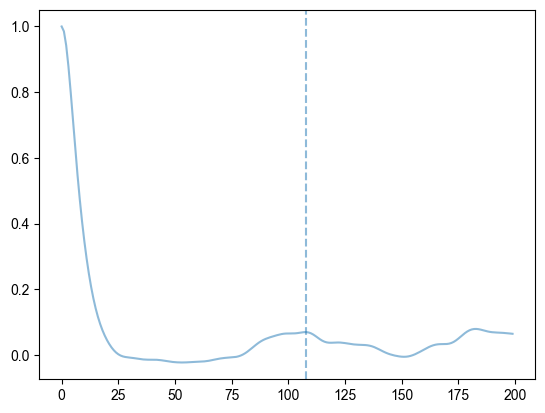

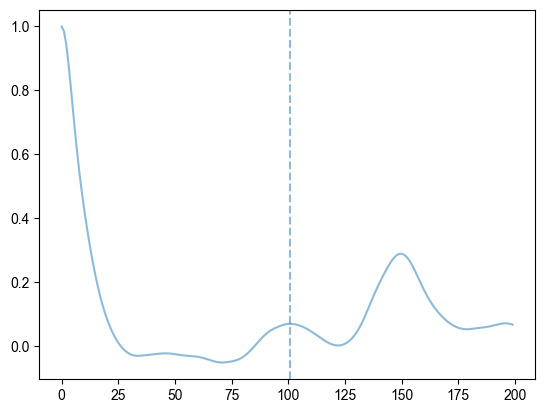

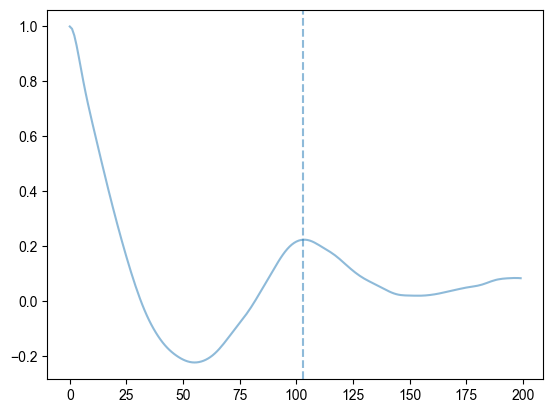

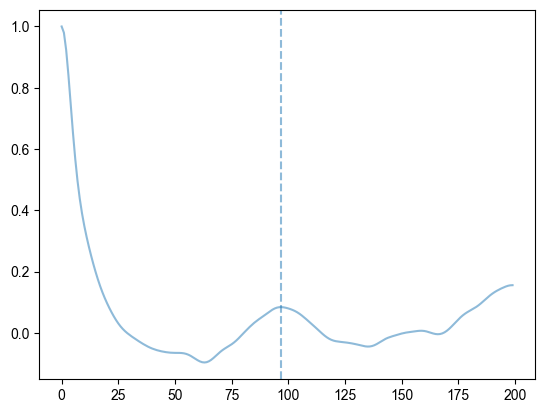

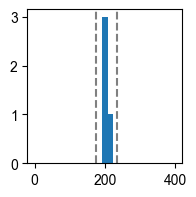

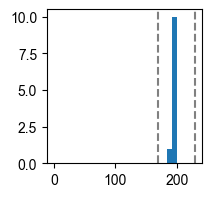

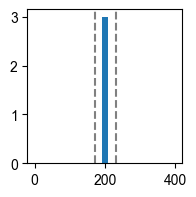

28 25
for module 1, there are 12 cells
for module 0, there are 3 cells


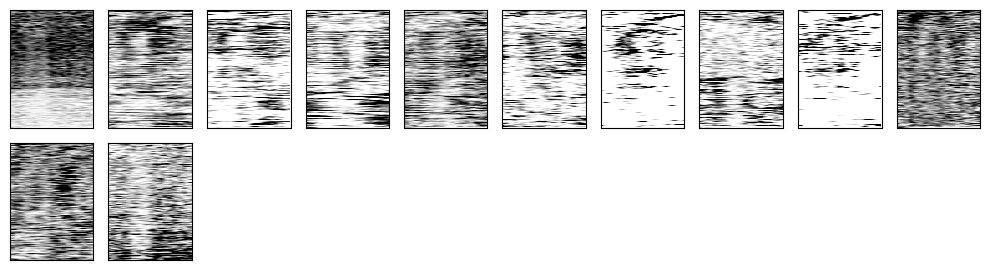

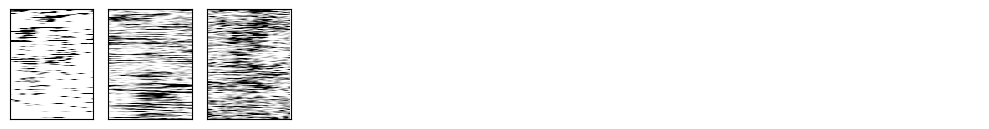

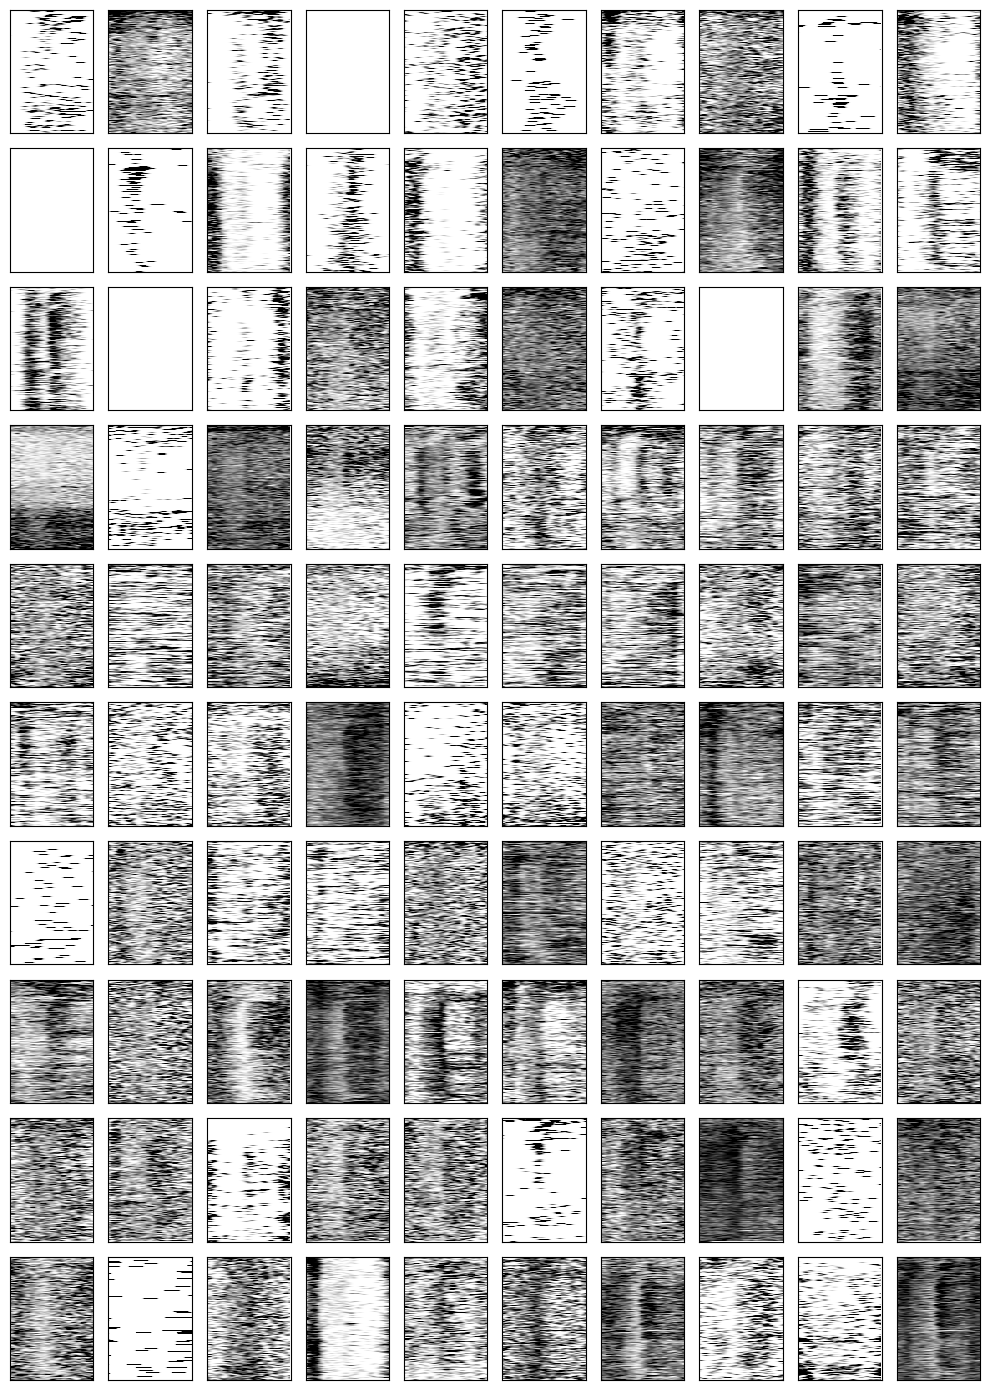

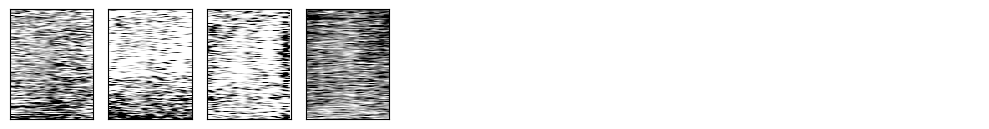

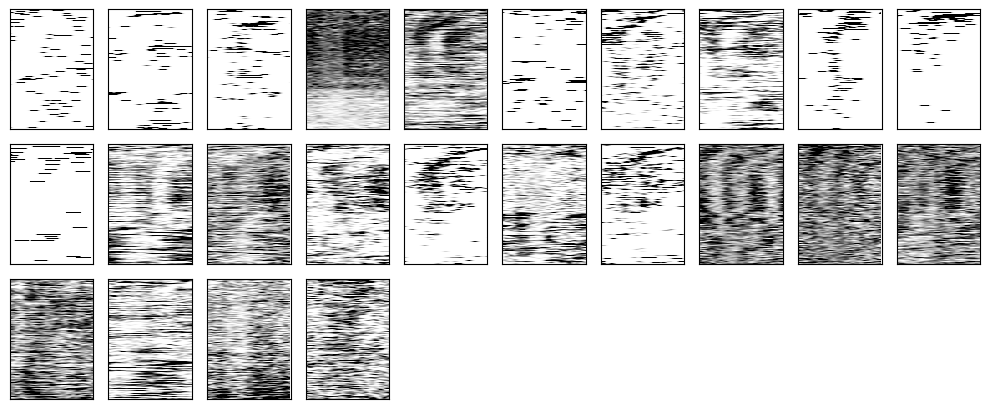

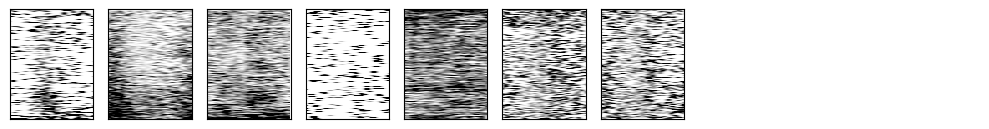

In [3]:
gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
rc, rsc, vr_ns = cell_classification_vr(mouse, day)

g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                figpath=fig_path, curate_with_vr=True, curate_with_brain_region=True) # create grid modules using HDBSCAN    

plot_grid_modules_rate_maps(gcs, g_m_ids, g_m_cluster_ids, mouse, day, figpath=fig_path)

# we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
# as defined by activity in the open field
g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
cluster_ids_by_group = []
cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]

for m, cluster_ids in enumerate(cluster_ids_by_group):
    plot_vr_rate_maps(mouse, day, cluster_ids, label=f'{m}', figpath=fig_path)

#plot_vr_rate_maps(mouse, day, rc.cluster_id.values, label=f'ramp_cells', figpath=fig_path)
#plot_vr_rate_maps(mouse, day, rsc.cluster_id.values, label=f'speed_ramp_cells', figpath=fig_path)

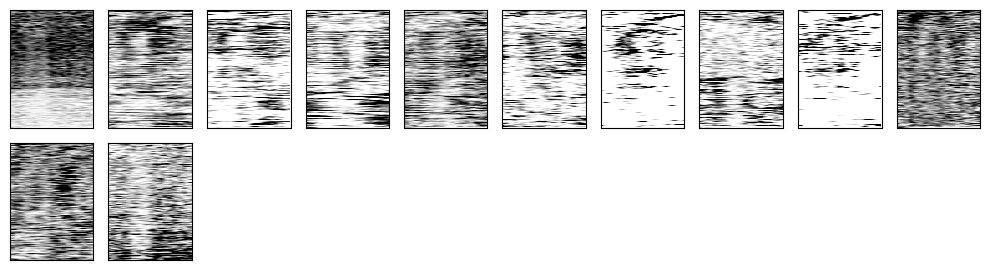

In [4]:
cluster_ids=cluster_ids_by_group[0]
tcs,tcs_time,_,_,_,_ = compute_vr_tcs(mouse, day)
ncols = 10
nrows = int(np.ceil(len(cluster_ids)/ncols))
fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=(10, 1.4*nrows), squeeze=False)
counter = 0
for j in range(nrows):
    for i in range(ncols):
        if counter<len(cluster_ids):
            index = cluster_ids[counter]
            plot_firing_rate_map(ax[j, i], 
                                zscore(tcs[index]),
                                bs=bs,
                                tl=tl,
                                p=95)
        else:
            ax[j, i].axis('off')
        counter+=1
        ax[j, i].set_xticks([])
        ax[j, i].set_yticks([])
        ax[j, i].xaxis.set_tick_params(labelbottom=False)
        ax[j, i].yaxis.set_tick_params(labelleft=False)
plt.tight_layout()
plt.show()

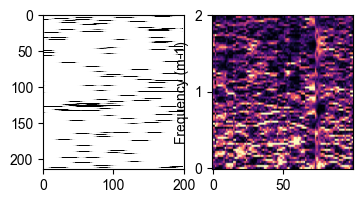

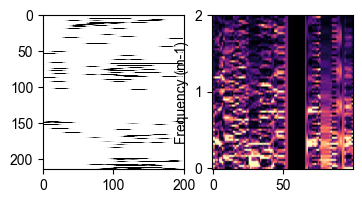

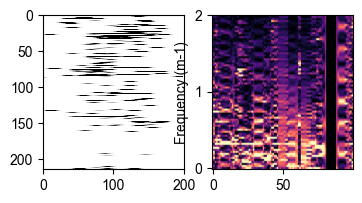

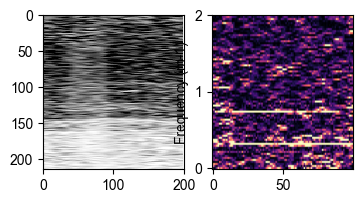

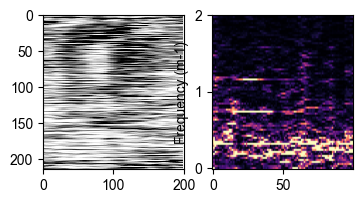

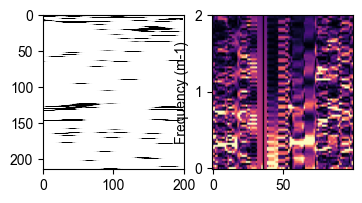

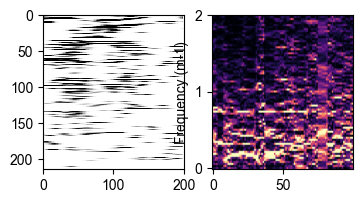

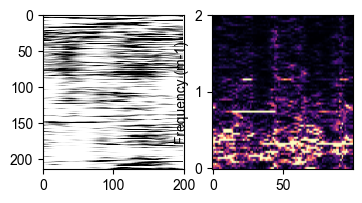

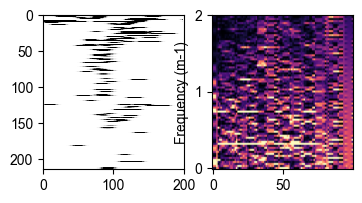

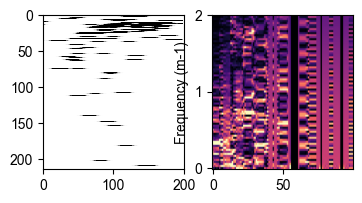

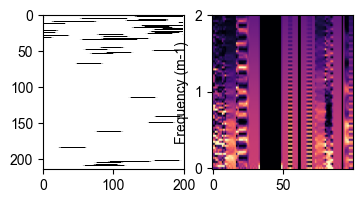

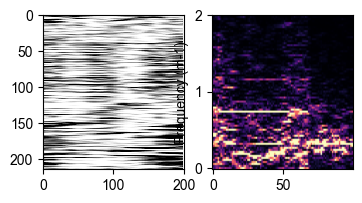

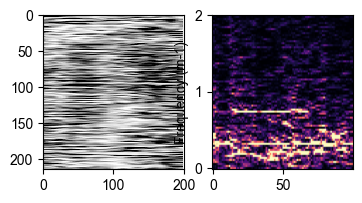

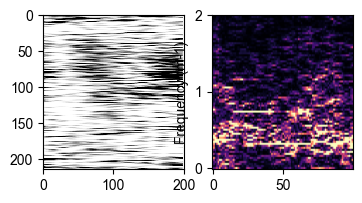

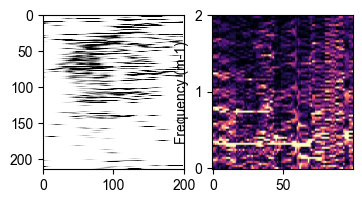

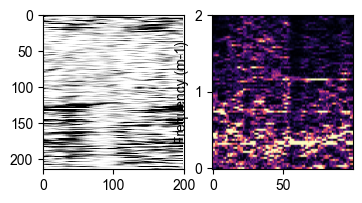

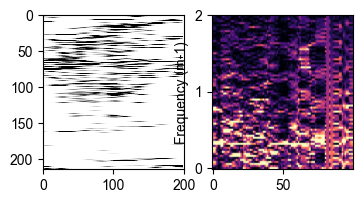

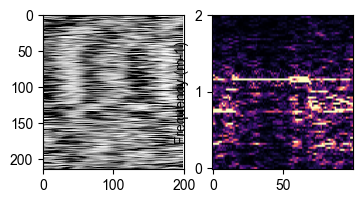

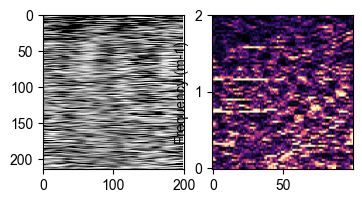

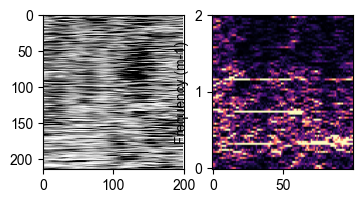

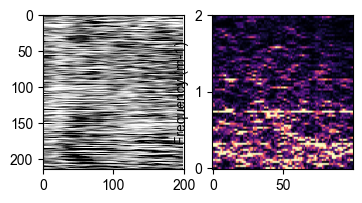

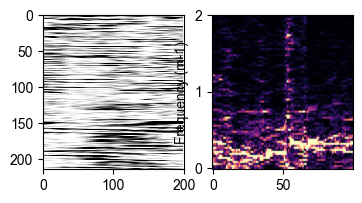

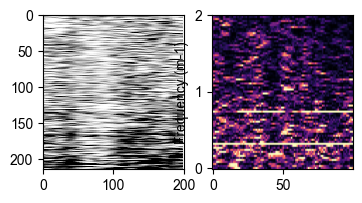

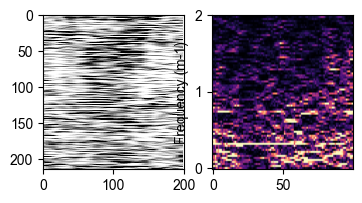

In [9]:
for id in gcs.cluster_id.values:
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in [id] if cluster_id in tcs}
    S, _, _, _ = get_spectrogram(tcs_to_use, tl, bs=bs)
    fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(4, 2))
    plot_firing_rate_map(ax[0],zscore(tcs[id]),bs=bs,tl=tl,p=95)
    S = S.mean(0)
    ax[1].imshow(S,origin='lower',aspect='auto',vmax=0.25,cmap='magma')
    ax[1].set_yticks([0, len(S)/2, len(S)], [0, 1, 2])
    ax[1].set_ylabel(f'Frequency (m-1)')
    plt.show()

/Users/harryclark/Downloads/kilosort4_sa
/Users/harryclark/Downloads/kilosort4_sa


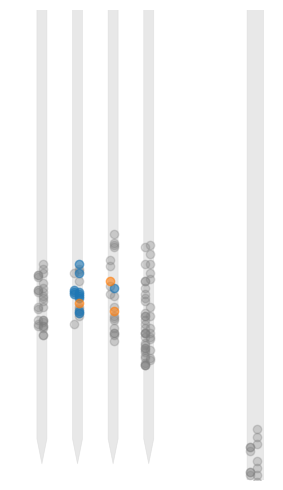

In [10]:

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(4, 5), squeeze=False)
plot_NP2_probe(ax[0,0], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa')
ax[0,0].scatter(ngs['probe_x'], ngs['probe_y'], color='tab:grey', alpha=0.3)
for m, cluster_ids in enumerate(g_m_cluster_ids):
    m_gcs = gcs[gcs.cluster_id.isin(cluster_ids)]
    ax[0,0].scatter(m_gcs['probe_x'], m_gcs['probe_y'], alpha=0.6)
ax[0,0].set_xlim(-200, 1000)
ax[0,0].set_ylim(-300, 3000)
plot_NP2_probe(ax[0,1], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa')
ax[0,1].scatter(ngs['probe_x'], ngs['probe_y'], color='tab:grey', alpha=0.3)
for m, cluster_ids in enumerate(g_m_cluster_ids):
    m_gcs = gcs[gcs.cluster_id.isin(cluster_ids)]
    ax[0,1].scatter(m_gcs['probe_x'], m_gcs['probe_y'], alpha=0.6)
ax[0,1].set_xlim([-25, 100])
ax[0,1].set_ylim([1000,3000])
plt.tight_layout()
plt.show()

Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


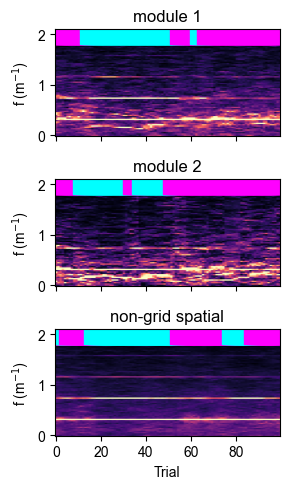

In [45]:
fig, ax = plt.subplots(nrows=(len(g_m_cluster_ids)+1), ncols=1, figsize=(3, 5), squeeze=False, sharex=True,)

for m in range(len(g_m_cluster_ids)):
    cluster_ids = g_m_cluster_ids[m]
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    S = spectrograms.mean(0)
    ax[m,0].set_title(f'module {m+1}')
    ax[m,0].imshow(S,origin='lower',aspect='auto',vmax=0.25,cmap='magma')
    ax[m,0].set_yticks([0, len(S)/2, len(S)], [0, 1, 2])
    ax[m,0].set_ylabel(r'f (m$^{-1}$)')

    kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
    labels = kmeans.fit_predict(S.T)
    ax[m,0].scatter(np.arange(S.shape[1]), [S.shape[0]]*S.shape[1], c=labels, cmap='cool', marker='s', s=200, label='Cluster')
    #max_peaks = np.argmax(S, axis=0)
    #ax[m,0].scatter(np.arange(len(max_peaks)), max_peaks, color='green', s=20)

    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    S = spectrograms.mean(0)
    ax[-1,0].set_title(f'non-grid spatial')
    ax[-1,0].imshow(S,origin='lower',aspect='auto',vmax=0.25,cmap='magma')
    ax[-1,0].set_yticks([0, len(S)/2, len(S)], [0, 1, 2])
    ax[-1,0].set_ylabel(r'f (m$^{-1}$)')
    ax[-1,0].set_xlabel('Trial')
    labels = kmeans.fit_predict(S.T)
    ax[-1,0].scatter(np.arange(S.shape[1]), [S.shape[0]]*S.shape[1], c=labels, cmap='cool', marker='s', s=200, label='Cluster')
    #max_peaks = np.argmax(S, axis=0)
    #ax[-1,0].scatter(np.arange(len(max_peaks)), max_peaks, color='green', s=20)
# make a ylabel for the whole y axis
plt.tight_layout()
plt.show()


Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


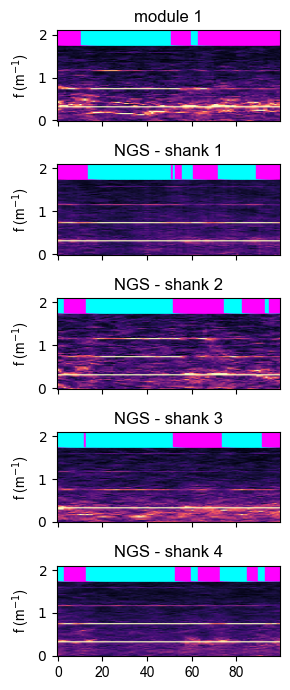

In [48]:
fig, ax = plt.subplots(nrows=5, ncols=1, figsize=(3, 7), squeeze=False, sharex=True)
cluster_ids = g_m_cluster_ids[0]
tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3] 
S = spectrograms.mean(0)
ax[0,0].set_title(f'module {1}')
ax[0,0].imshow(S,origin='lower',aspect='auto',vmax=0.25,cmap='magma')
ax[0,0].set_yticks([0, len(S)/2, len(S)], [r'$0$', r'$1$', r'$2$'])
ax[0,0].set_ylabel(r'f (m$^{-1}$)')
kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
labels = kmeans.fit_predict(S.T)
ax[0,0].scatter(np.arange(S.shape[1]), [S.shape[0]]*S.shape[1], c=labels, cmap='cool', marker='s', s=200, label='Cluster')

for s in [0,1,2,3]:
    shank_ngs = ngs[(ngs.probe_x >= (s*250)) & (ngs.probe_x <= (50+(s*250)))]
    cluster_ids = shank_ngs.cluster_id.values
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    S = spectrograms.mean(0)
    ax[s+1,0].set_title(f'NGS - shank {s+1}')
    ax[s+1,0].imshow(S,origin='lower',aspect='auto',vmax=0.25,cmap='magma')
    ax[s+1,0].set_yticks([0, len(S)/2, len(S)], [r'$0$', r'$1$', r'$2$'])
    ax[s+1,0].set_ylabel(r'f (m$^{-1}$)')
    labels = kmeans.fit_predict(S.T)
    ax[s+1,0].scatter(np.arange(S.shape[1]), [S.shape[0]]*S.shape[1], c=labels, cmap='cool', marker='s', s=200, label='Cluster')

plt.tight_layout()
plt.show()

Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


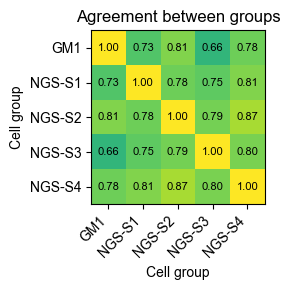

In [49]:
group_names = ['GM1', 'NGS-S1', 'NGS-S2', 'NGS-S3', 'NGS-S4']
group_labels = []
group_spectrograms = []

cluster_ids = g_m_cluster_ids[0]
tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3] 
S = spectrograms.mean(0)
kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
labels = kmeans.fit_predict(S.T)
group_labels.append(labels)
group_spectrograms.append(S)

for s in [0,1,2,3]:
    shank_ngs = ngs[(ngs.probe_x >= (s*250)) & (ngs.probe_x <= (50+(s*250)))]
    cluster_ids = shank_ngs.cluster_id.values
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    S = spectrograms.mean(0)
    kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
    labels = kmeans.fit_predict(S.T)
    group_labels.append(labels)
    group_spectrograms.append(S)

# calculate agreement between groups
agreements = np.zeros((len(group_spectrograms), len(group_spectrograms)))
for i, m in enumerate(range(len(group_spectrograms))):
    for j, n in enumerate(range(len(group_spectrograms))):
        agreements[i, j] = np.sum(group_labels[i] == group_labels[j]) / len(group_labels[i])


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 3), squeeze=False)
ax[0,0].imshow(agreements, cmap='viridis', vmin=0, vmax=1)
# offset the x and y ticks to be the group names
ax[0,0].set_xticks(np.arange(len(group_names)))
ax[0,0].set_yticks(np.arange(len(group_names)))
ax[0,0].set_xticklabels(group_names, rotation=45, ha='right')
ax[0,0].set_yticklabels(group_names)
ax[0,0].set_xlabel('Cell group')
ax[0,0].set_ylabel('Cell group')

ax[0,0].set_title('Agreement between groups')   
# add agreeement values to the cells
for i in range(len(group_names)):
    for j in range(len(group_names)):
        ax[0,0].text(j, i, f'{agreements[i, j]:.2f}', ha='center', va='center', color='black', fontsize=8)
plt.tight_layout()    
plt.show()

Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


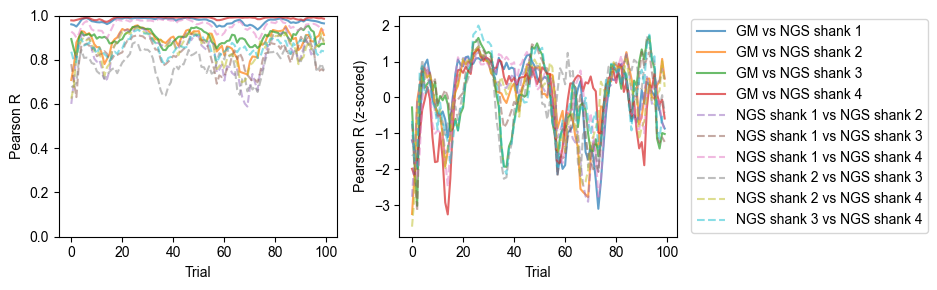

In [46]:
from scipy import stats

# Prepare spectrograms for GM and each NGS shank
Ss = []
# GM (grid module)
Ss.append(spectrograms.mean(0))

# NGS shanks (shank 1 to 4)
for s in [0, 1, 2, 3]:
    shank_ngs = ngs[(ngs.probe_x >= (s*250)) & (ngs.probe_x <= (50+(s*250)))]
    cluster_ids = shank_ngs.cluster_id.values
    tcs_shank = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_shank, tl, bs=bs)
    spectrograms_shank = results[3]
    S = spectrograms_shank.mean(0)
    Ss.append(S)

labels = ['GM', 'NGS shank 1', 'NGS shank 2', 'NGS shank 3', 'NGS shank 4']

# Pearson comparisons
gm_vs_shank_corrs = []
shank_vs_shank_corrs = []

for i in range(1, len(Ss)):
    # GM vs each shank
    corrs = [stats.pearsonr(Ss[0][:, t], Ss[i][:, t])[0] for t in range(Ss[0].shape[1])]
    gm_vs_shank_corrs.append(corrs)

# Shank vs shank
for i in range(1, len(Ss)):
    for j in range(i+1, len(Ss)):
        corrs = [stats.pearsonr(Ss[i][:, t], Ss[j][:, t])[0] for t in range(Ss[i].shape[1])]
        shank_vs_shank_corrs.append((i, j, corrs))

# Plotting
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 3), squeeze=False)
for i, corrs in enumerate(gm_vs_shank_corrs):
    ax[0,0].plot(corrs, label=f'GM vs {labels[i+1]}', alpha=0.7)
    ax[0,1].plot(zscore(corrs), label=f'GM vs {labels[i+1]}', alpha=0.7)

for i, j, corrs in shank_vs_shank_corrs:
    ax[0,0].plot(corrs, label=f'{labels[i]} vs {labels[j]}', linestyle='--', alpha=0.5)
    ax[0,1].plot(zscore(corrs), label=f'{labels[i]} vs {labels[j]}', linestyle='--', alpha=0.5)

ax[0,0].set_xlabel('Trial')
ax[0,1].set_xlabel('Trial')
ax[0,0].set_ylabel('Pearson R')
ax[0,1].set_ylabel('Pearson R (z-scored)')
ax[0,0].set_ylim(0, 1)
plt.tight_layout()
ax[0,1].legend(loc='center left', bbox_to_anchor=(1.05, 0.5), borderaxespad=0.)
plt.show()

In [ ]:
for s in [0, 1, 2, 3]:
    shank_ngs = ngs[(ngs.probe_x >= (s*250)) & (ngs.probe_x <= (50+(s*250)))]
    cluster_ids = shank_ngs.cluster_id.values
    plot_individual_rate_maps_with_avg_k_means_grouped_spectrogram(mouse, day, cluster_ids=cluster_ids, label=f'_module{m}_', figpath='/Users/harryclark/Documents/figs/rate_maps_by_shank/')
    plot_individual_rate_maps_with_avg(mouse, day, cluster_ids=cluster_ids, label=f'_module{m}_', figpath='/Users/harryclark/Documents/figs/rate_maps_by_shank/')
plot_individual_rate_maps_with_avg_k_means_grouped_spectrogram(mouse, day, cluster_ids=g_m_cluster_ids[0], label=f'_module0_', figpath='/Users/harryclark/Documents/figs/rate_maps_by_shank/')


In [ ]:
for s in [0, 1, 2, 3]:
    shank_ngs = ngs[(ngs.probe_x >= (s*250)) & (ngs.probe_x <= (50+(s*250)))]
    cluster_ids = shank_ngs.cluster_id.values
    plot_individual_rate_maps_with_avg(mouse, day, cluster_ids=cluster_ids, label=f'_shank{s}_', figpath='/Users/harryclark/Documents/figs/rate_maps_by_grid_module/')